In [49]:
import struct
import math
import time
import csv

import casadi as ca
import numpy as np
from matplotlib import pyplot as plt

from scipy.spatial.transform import Rotation as R
from ahrs.common.orientation import acc2q
from ahrs import Quaternion

from scipy.signal import butter, filtfilt, lfilter, lfilter_zi

mincopter log: 47 entries with max 306 records and min 306
GPS lat: [-353632619, -353632619, -353632619, -353632619, -353632619]
GPS lng: [1491652370, 1491652370, 1491652370, 1491652370, 1491652370]
GPS alt: [0, 0, 0, 0, 0]


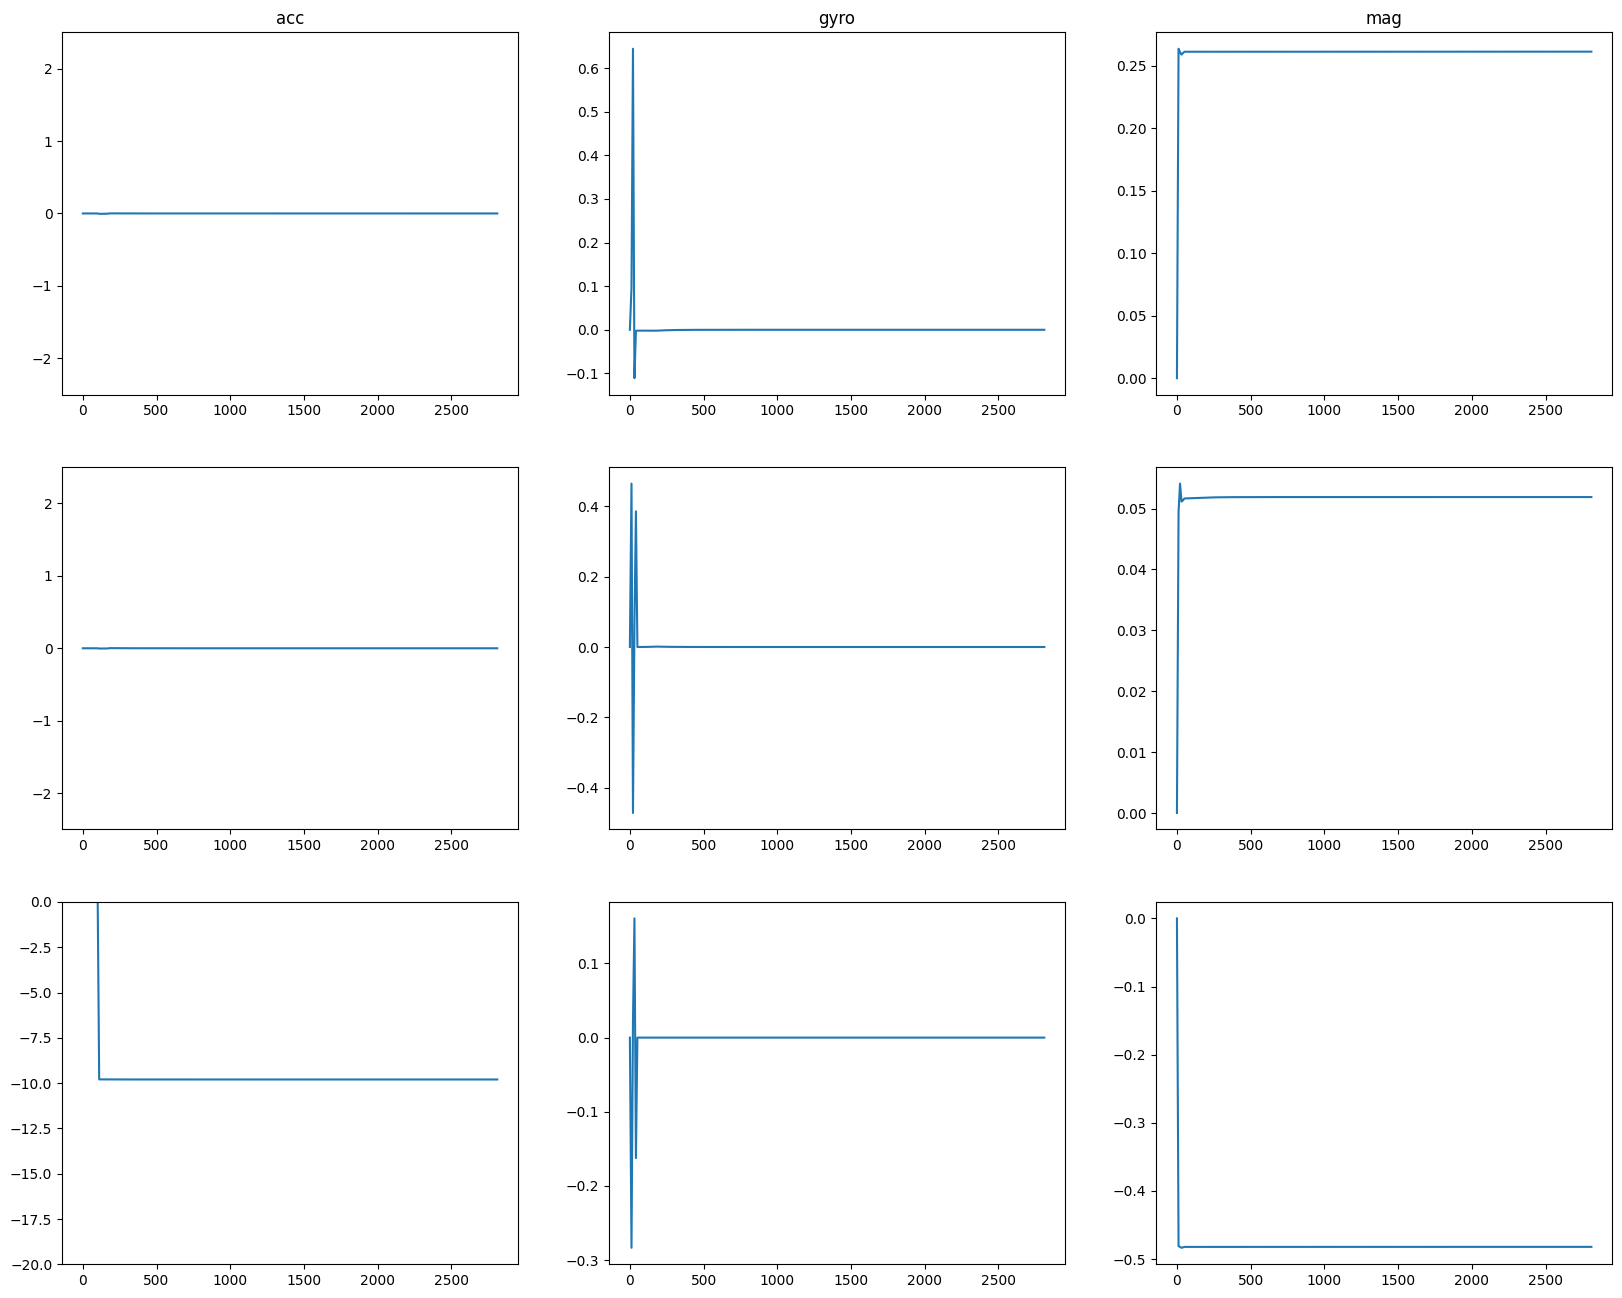

In [53]:
'''Read raw values'''
from parse import Parser
import random

parser = Parser()
mc_x, mc_y = parser.read_mincopter_log('../../build-generic/mincopter_log.txt')
gz_x, gz_y = parser.read_gz_log('/tmp/gz_imu_logfile.txt')

print(f'mincopter log: {len(mc_y.keys())} entries with max {max([len(mc_y[e]) for e in mc_y.keys()])} records \
and min {min([len(mc_y[e]) for e in mc_y.keys()])}')

print(f'GPS lat: {random.sample(mc_y['gps_lat'],5)}')
print(f'GPS lng: {random.sample(mc_y['gps_lng'],5)}')
print(f'GPS alt: {random.sample(mc_y['gps_alt_cm'],5)}')

fig, ax = plt.subplots(3,3, figsize=(20,16))

ax[0,0].set_title('acc')
ax[0,1].set_title('gyro')
ax[0,2].set_title('mag')

ax[0,0].plot(mc_x['accel_x'], mc_y['accel_x'])
ax[0,0].set_ylim(-2.5,2.5)
ax[1,0].plot(mc_x['accel_y'], mc_y['accel_y'])
ax[1,0].set_ylim(-2.5,2.5)
ax[2,0].plot(mc_x['accel_z'], mc_y['accel_z'])
ax[2,0].set_ylim(-20,0)

ax[0,1].plot(mc_x['gyro_x'], mc_y['gyro_x'])
ax[1,1].plot(mc_x['gyro_y'], mc_y['gyro_y'])
ax[2,1].plot(mc_x['gyro_z'], mc_y['gyro_z'])
ax[0,2].plot(mc_x['comp_x'], mc_y['comp_x'])
ax[1,2].plot(mc_x['comp_y'], mc_y['comp_y'])
ax[2,2].plot(mc_x['comp_z'], mc_y['comp_z']);

## Accelerometer Filtering (20Hz)

[0.0591907 0.0591907] [ 1.         -0.88161859]


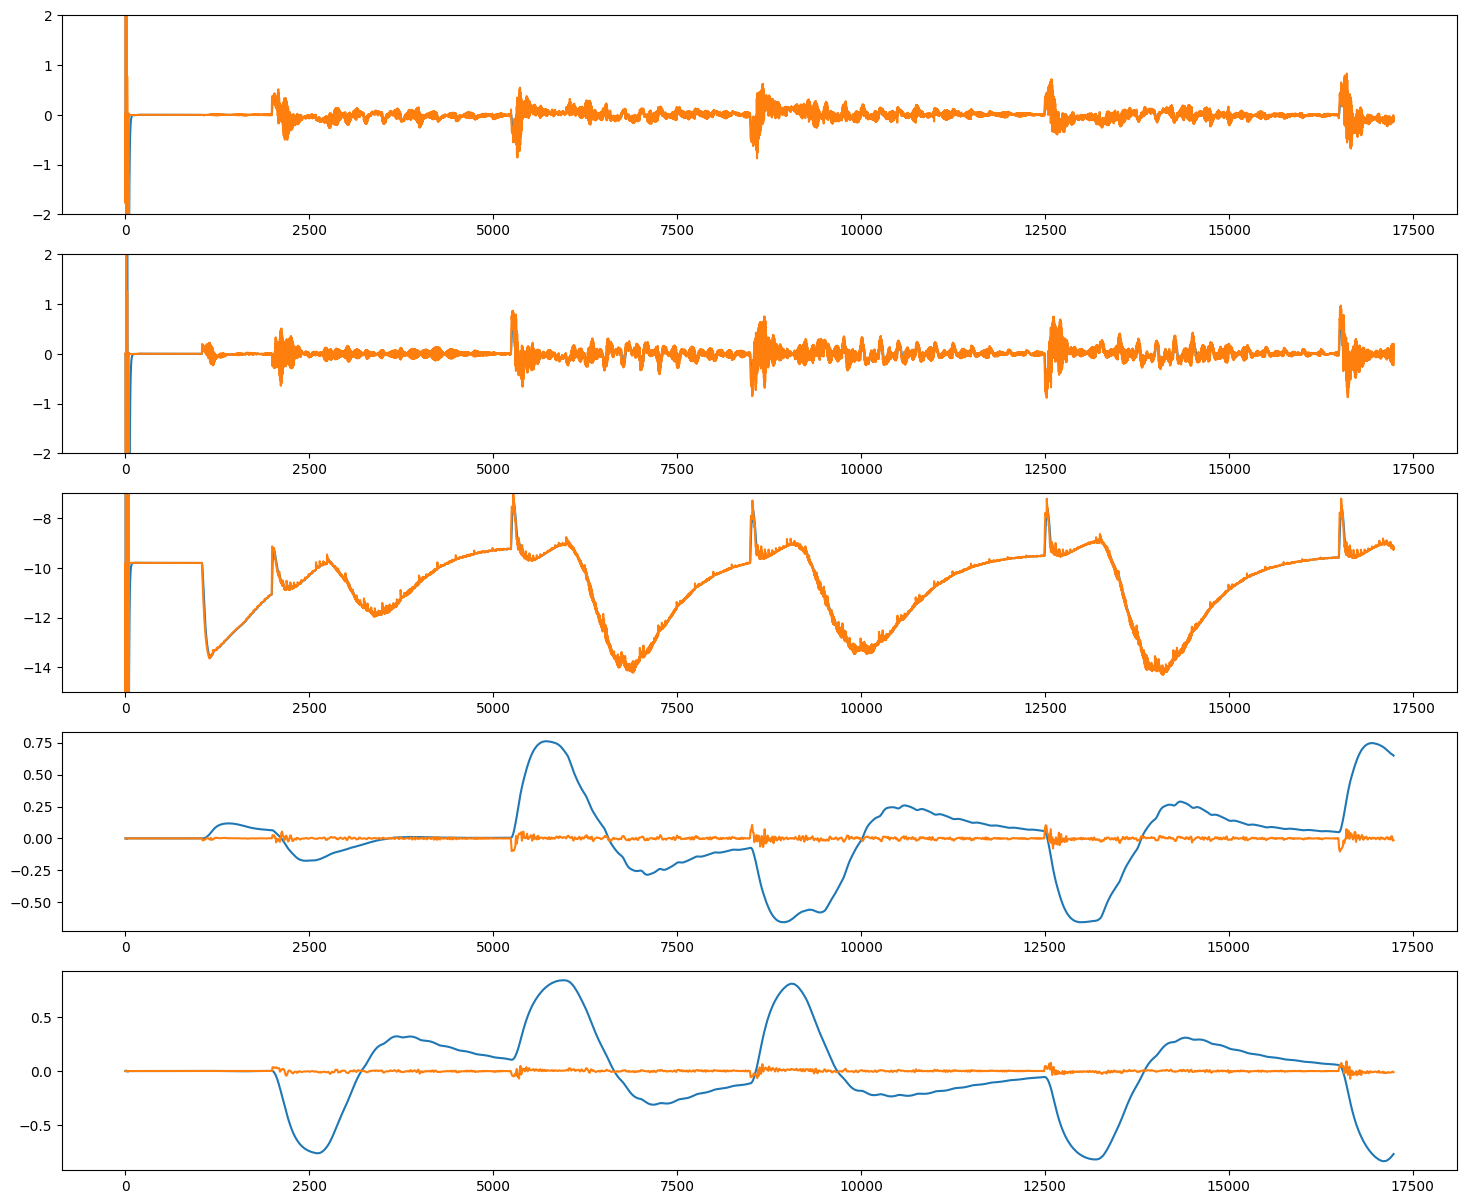

In [51]:
fs = 1000  # sampling frequency (Hz)
order = 1
cutoff = 20  # cutoff frequency (Hz)
normal_cutoff = cutoff / (fs / 2)  # normalized cutoff
b, a = butter(order, normal_cutoff, btype='low', analog=False)

print(b,a)
'''
zf = lfilter_zi(b, a) * 0
new_acc_x = []
for i in range(0,len(gz_y['ax'])):
    y, zf = lfilter(b,a, [gz_y['ax'][i]], zi=zf)
    new_acc_x.append(y)
'''

ax_filtered = lfilter(b, a, gz_y['ax'])
ay_filtered = lfilter(b, a, gz_y['ay'])
az_filtered = lfilter(b, a, gz_y['az'])

fig, ax = plt.subplots(5,1,figsize=(18,15))
rmin = 0
rmax = -1
ax[0].plot(gz_x['ax'][rmin:rmax], ax_filtered[rmin:rmax])
ax[0].plot(gz_x['ax'][rmin:rmax], gz_y['ax'][rmin:rmax])
ax[0].set_ylim(-2,2)
ax[1].plot(gz_x['ay'][rmin:rmax], ay_filtered[rmin:rmax])
ax[1].plot(gz_x['ay'][rmin:rmax], gz_y['ay'][rmin:rmax])
ax[1].set_ylim(-2,2)
ax[2].plot(gz_x['az'][rmin:rmax], az_filtered[rmin:rmax])
ax[2].plot(gz_x['az'][rmin:rmax], gz_y['az'][rmin:rmax])
ax[2].set_ylim(-15,-7)

ax[3].plot(mc_x['roll'], mc_y['roll'])
ax[4].plot(mc_x['pitch'], mc_y['pitch'])

roll_inferred_gz = [math.atan2(-mc_y['accel_y'][i], -mc_y['accel_z'][i]) for i in range(0,len(mc_y['accel_x']))]
ax[3].plot(mc_x['roll'], roll_inferred_gz)

pitch_inferred_gz = [math.atan2(mc_y['accel_x'][i], math.sqrt(mc_y['accel_y'][i]**2+mc_y['accel_z'][i]**2)) for i in range(0,len(mc_y['accel_x']))]
ax[4].plot(mc_x['pitch'], pitch_inferred_gz)


We can try and re-create the expected accelerometer reading using the derivative of the (actual) velocity and the (actual) attitude.
$$\begin{align}\begin{bmatrix}a_{x} \\ a_{y} \\ a_{z}\end{bmatrix} &=
\begin{bmatrix} a_{x,body} \\ a_{y,body} \\ a_{z,body}
\end{bmatrix} + \mathbf{g}_{body} \\ &= R^{T}a_{inertial} + R^{T}g_{inertial} \end{align}
$$

## Gyrometer Filtering (2Hz)

[0.00624404 0.00624404] [ 1.         -0.98751193]


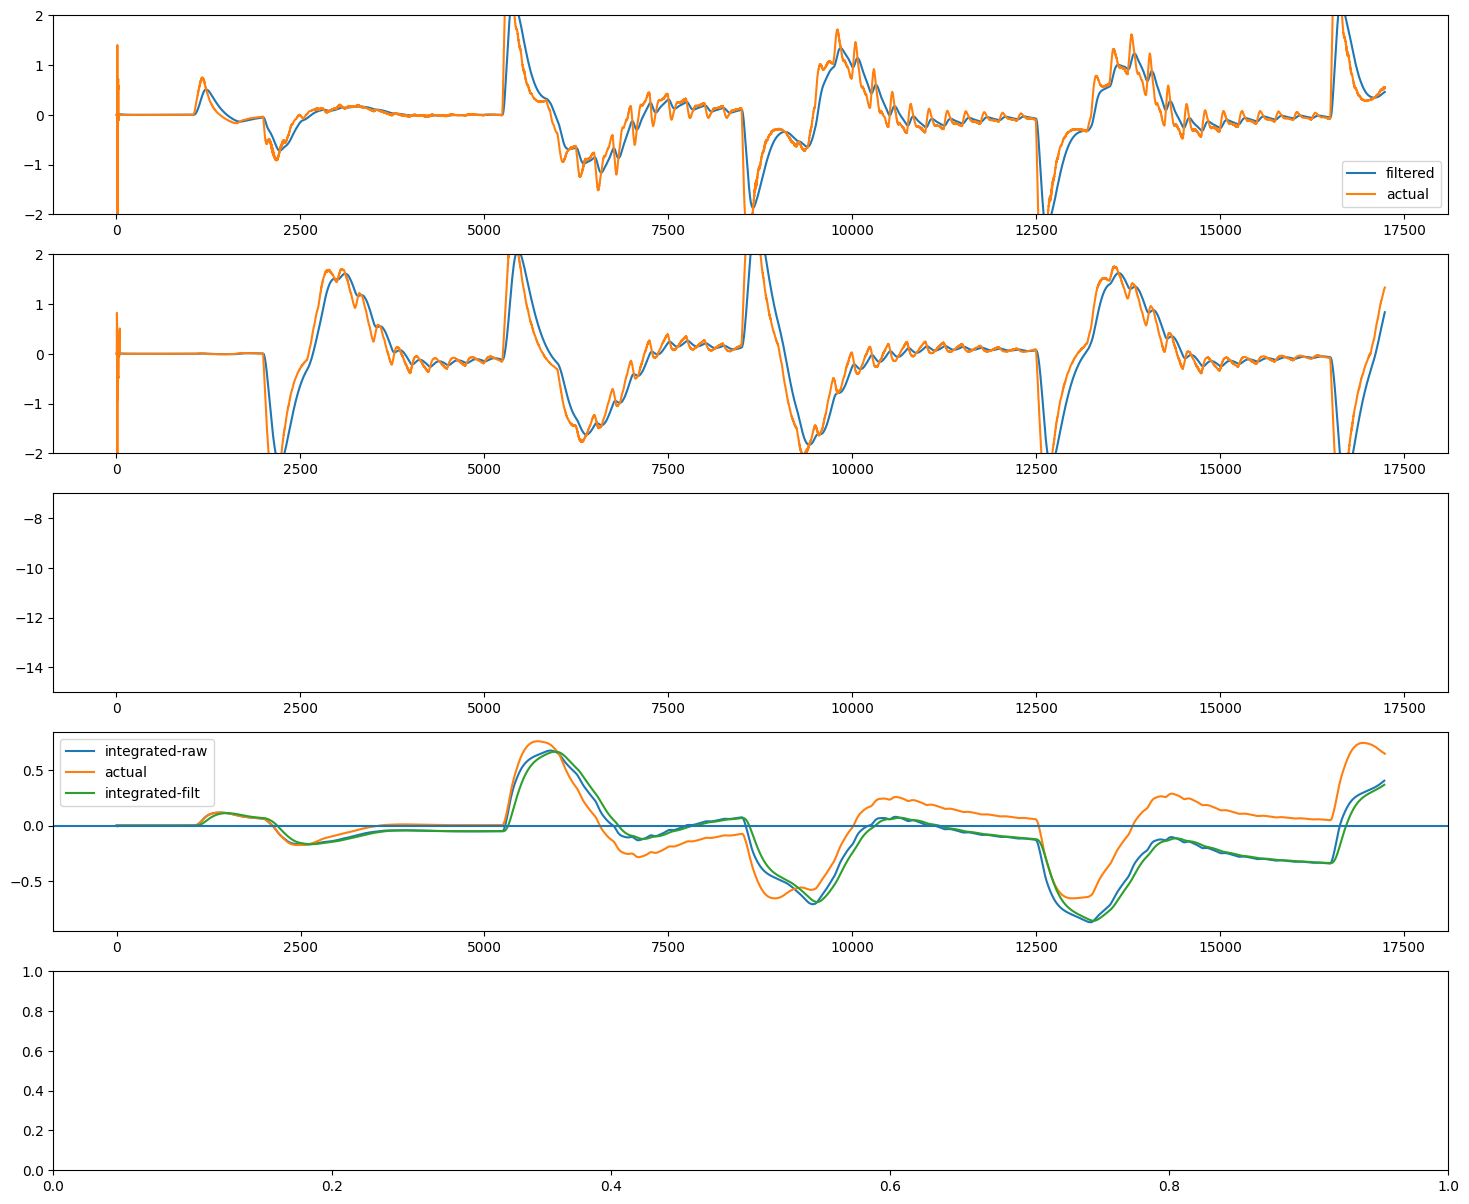

In [52]:
fs = 1000  # sampling frequency (Hz)
order = 1
cutoff = 2  # cutoff frequency (Hz)
normal_cutoff = cutoff / (fs / 2)  # normalized cutoff
b, a = butter(order, normal_cutoff, btype='low', analog=False)

print(b,a)
'''
zf = lfilter_zi(b, a) * 0
new_acc_x = []
for i in range(0,len(gz_y['ax'])):
    y, zf = lfilter(b,a, [gz_y['ax'][i]], zi=zf)
    new_acc_x.append(y)
'''

ax_filtered = lfilter(b, a, gz_y['gx'])
ay_filtered = lfilter(b, a, gz_y['gy'])
az_filtered = lfilter(b, a, gz_y['gz'])

fig, ax = plt.subplots(5,1,figsize=(18,15))
rmin = 0
rmax = -1
ax[0].plot(gz_x['ax'][rmin:rmax], ax_filtered[rmin:rmax], label='filtered')
ax[0].plot(gz_x['ax'][rmin:rmax], gz_y['gx'][rmin:rmax], label='actual')
ax[0].legend()
ax[0].set_ylim(-2,2)
ax[1].plot(gz_x['ay'][rmin:rmax], ay_filtered[rmin:rmax])
ax[1].plot(gz_x['ay'][rmin:rmax], gz_y['gy'][rmin:rmax])
ax[1].set_ylim(-2,2)
ax[2].plot(gz_x['az'][rmin:rmax], az_filtered[rmin:rmax])
ax[2].plot(gz_x['az'][rmin:rmax], gz_y['gz'][rmin:rmax])
ax[2].set_ylim(-15,-7)

roll_integrated_raw = []
roll_integrated_filt = []
for i,e in enumerate(gz_y['gx']):
    roll_integrated_raw.append(roll_integrated_raw[i-1] + 0.001*e if i!=0 else 0)

for i,e in enumerate(ax_filtered):
    roll_integrated_filt.append(roll_integrated_filt[i-1] + 0.001*e if i!=0 else 0)


ax[3].plot(roll_integrated_raw, label='integrated-raw')
ax[3].plot(mc_x['roll'], mc_y['roll'], label='actual')
ax[3].plot(roll_integrated_filt, label='integrated-filt')
ax[3].axhline(y=0)
ax[3].legend()

In [48]:
## Temporary roll,pitch,yaw
troll=0
tpitch=0
tyaw=0

lowest_mse_div = 1e9
lowest_fuse_pc = 1e9
lowest_mse = 1e9

iterations = min(len(mc_y['roll'])*10, max(gz_x['ax']))

for div_max in np.linspace(0,5,100):
    for fuse_pc in np.linspace(0,0.1,20):

        mse = 0
        for i in range(0,iterations,10):
            ## Retrieve every 10th reading (100Hz)
        
            pitch_acc = math.atan2(gz_y['ax'][i], math.sqrt(gz_y['ay'][i]**2 + gz_y['az'][i]**2))
            roll_acc = math.atan2(-gz_y['ay'][i], -gz_y['az'][i])
        
            ## Integrate gyro
            roll_gyr = troll + 0.01*gz_y['gx'][i]
            pitch_gyr = tpitch + 0.01*gz_y['gy'][i]
                        
            ## Fuse with a weight based on how much we are accelerating
            a_norm = math.sqrt(gz_y['ax'][i]**2 + gz_y['ay'][i]**2 + gz_y['az'][i]**2)
                    
            div = abs(a_norm-9.8)
            if div>div_max:
                ## Ignore accel reading altogether
                a = 1
            else:
                ## Accel reading should by up to 2% of the fused value when we are stationary
                a = 1 - (div_max-div)*fuse_pc/div_max
            
            troll = a*roll_gyr + (1-a)*roll_acc
            tpitch = a*pitch_gyr + (1-a)*pitch_acc

            mse += (troll-mc_y['roll'][i//10])**2

        if mse<lowest_mse:
            lowest_mse = mse
            lowest_mse_div = div_max
            lowest_fuse_pc = fuse_pc

print(lowest_mse, lowest_fuse_pc, lowest_mse_div)


25.744426135526737 0.1 0.20202020202020202
